<a href="https://colab.research.google.com/github/alinelima1909/Python_Data_Science.ipynb/blob/main/Dadosprogramaria13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Conectando SQL em Pandas

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
conexao = sqlite3.connect('/content/drive/MyDrive/Programaria/SQL/Status Brasil')

In [ ]:
query ="SELECT* FROM Municipios_Brasileiros WHERE Cidade= 'Itaquaquecetuba';"

In [ ]:
import numpy as np
import pandas as pd
import sqlite3

# Ensure conexao and dados are defined, primarily for independent execution
# For results based on merged data, ensure cell Ge0M1GqsfGEK is run beforehand.
if 'conexao' not in locals():
    conexao = sqlite3.connect('/content/drive/MyDrive/Programaria/SQL/Status Brasil')
    print("conexao was not defined, initialized in this cell.")

if 'dados' not in locals():
    dados = pd.read_csv('/content/drive/MyDrive/Programaria/analise_dados.csv')
    if 'UF ONDE MORA' in dados.columns:
        dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace=True)
    print("dados was not defined, loaded and renamed in this cell.")
elif 'Estado' not in dados.columns and 'UF ONDE MORA' in dados.columns:
    # If dados exists but hasn't been renamed yet (e.g., if Ge0M1GqsfGEK was partially run or 'dados' was reloaded elsewhere)
    dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace=True)
    print("dados column 'UF ONDE MORA' renamed to 'Estado'.")

# Define lista_estados from the 'Estado' column of the 'dados' DataFrame.
# If Ge0M1GqsfGEK was run, 'dados' contains merged data. Otherwise, it's from the original CSV.
lista_estados = list(dados['Estado'].unique())

# Clean lista_estados by removing NaN values
lista_estados_cleaned = [x for x in lista_estados if pd.notna(x)]

# Create placeholders for the SQL IN clause based on the cleaned list
placeholders = ','.join(['?' for _ in lista_estados_cleaned])

# Construct the SQL query string with corrected JOIN condition and IN clause
# Assuming 'municipio_ID' is the correct join key between the two tables
# and 'Estado' from Municipios_Brasileiros is being filtered.
# Using aliases for readability (MB for Municipios_Brasileiros, MS for Municipios_Status)
query = f'''SELECT MB.Estado,
       AVG(MS.renda)
       FROM Municipios_Brasileiros AS MB
       INNER JOIN Municipios_Status AS MS ON
       MB.municipio_ID = MS.municipio_ID AND
       MB.Estado IN ({placeholders})
       GROUP BY MB.Estado;'''

# Execute the SQL query with the cleaned list of states as parameters
df_result = pd.read_sql(query, con=conexao, params=lista_estados_cleaned)
print(df_result)

dados was not defined, loaded and renamed in this cell.
   Estado  AVG(MS.renda)
0      AL       0.548363
1      AM       0.545113
2      BA       0.574805
3      CE       0.559293
4      DF       0.863000
5      ES       0.680628
6      GO       0.683980
7      MA       0.531664
8      MG       0.652008
9      MS       0.687846
10     MT       0.682149
11     PA       0.572357
12     PB       0.564423
13     PE       0.574378
14     PI       0.546813
15     PR       0.691962
16     RJ       0.704796
17     RN       0.580183
18     RS       0.722115
19     SC       0.728038
20     SE       0.577147
21     SP       0.716571


In [ ]:
lista_estados = list(dados['Estado']. unique())

In [ ]:
query= '''SELECT Municipios_Brasileiros.Estado,
       AVG(Municipios_Status.renda)
       FROM Municipios_Brasileiros
       INNER JOIN Municipios_Status ON
       Municipios_Brasileiros.municipio_ID = Municipios_Status.municipio_ID AND
       Municipios_Brasileiros.Estado IN ({})
       GROUP BY Municipios_Brasileiros.Estado;'''. format (','.join(['?' for _ in lista_estados]))

In [ ]:
print(query)

SELECT Municipios_Brasileiros.Estado,
       AVG(Municipios_Status.renda)
       FROM Municipios_Brasileiros
       INNER JOIN Municipios_Status ON
       Municipios_Brasileiros.municipio_ID = Municipios_Status.municipio_ID AND
       Municipios_Brasileiros.Estado IN (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
       GROUP BY Municipios_Brasileiros.Estado;


In [ ]:
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

In [ ]:
dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace= True)

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'Novo Nivel', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
import pandas as pd
import sqlite3

# Define conexao
conexao = sqlite3.connect('/content/drive/MyDrive/Programaria/SQL/Status Brasil')

# Load dados and rename column
dados = pd.read_csv('/content/drive/MyDrive/Programaria/analise_dados.csv')
dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace=True)

# Define lista_estados
# Use the new column name 'Estado' after renaming
lista_estados = list(dados['Estado'].unique())

# Define query
# Note: A placeholder '?' is used for each item in lista_estados in the SQL IN clause.
query = '''SELECT Municipios_Brasileiros.Estado,
       AVG(Municipios_Status.renda)
       FROM Municipios_Brasileiros
       INNER JOIN Municipios_Status ON
       Municipios_Brasileiros.municipio_ID = Municipios_Status.municipio_ID AND
       Municipios_Brasileiros.Estado IN ({})
       GROUP BY Municipios_Brasileiros.Estado;'''.format(','.join(['?' for _ in lista_estados]))

# Define estados_renda
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

# Perform merge
dados= merged_data = dados.merge(estados_renda, on="Estado", how='left')

# Display the head of the merged data
print(merged_data.head())

   Unnamed: 0                                ID  IDADE FAIXA IDADE     GENERO  \
0           0  zzqzz3l9ily8nuo2m7wyzzqzz3w48o96   39.0       35-39  Masculino   
1           1  zzls2oftfn9law393oezzls2ofhvfpzd   32.0       30-34  Masculino   
2           2  zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi   53.0       50-54  Masculino   
3           3  zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl   27.0       25-29  Masculino   
4           4  zzaf1m95yan929rb94wzzaf1mekhvhpg   46.0       45-49   Feminino   

  COR/RACA/ETNIA  PCD               EXPERIENCIA_PROFISSIONAL_PREJUDICADA  \
0          Parda  Não  Não acredito que minha experiência profissiona...   
1          Parda  Não  Sim, acredito que a minha a experiência profis...   
2         Branca  Não                                                NaN   
3         Branca  Não                                                NaN   
4         Branca  Não  Não acredito que minha experiência profissiona...   

                          ASPECTOS_PREJUDICADOS  VIVE_NO

In [ ]:
correlacao_renda_salario = merged_data['SALARIO'].corr(merged_data['AVG(Municipios_Status.renda)'])
correlacao_renda_salario

np.float64(0.07248631571592302)

In [ ]:
dados= pd.read_csv('/content/drive/MyDrive/Programaria/analise_dados.csv')

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'Novo Nivel', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
lista_estados = list(dados['UF ONDE MORA'].unique())

###Visualização de Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd


In [ ]:
dados = pd.read_csv('/content/drive/MyDrive/Programaria/analise_dados - analise_dados.csv')

In [ ]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,False,True
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,False,True
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True


In [ ]:
genero_counts =dados['GENERO'].value_counts()

In [ ]:
import matplotlib.pyplot as plt


<function matplotlib.pyplot.show(close=None, block=None)>

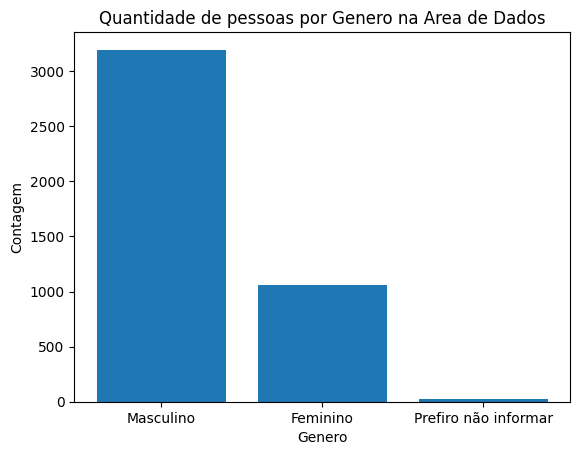

In [ ]:
plt.figure()
plt.bar(height = genero_counts.values, x= genero_counts.index)
plt.title('Quantidade de pessoas por Genero na Area de Dados')
plt.xlabel('Genero')
plt.ylabel('Contagem')
plt.show

In [ ]:
import seaborn as sns

/tmp/ipykernel_12954/376871995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='GENERO', palette='pastel')


<function matplotlib.pyplot.show(close=None, block=None)>

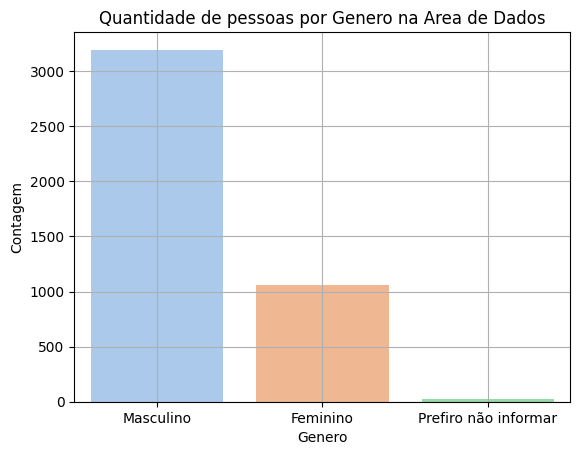

In [ ]:
plt.figure()
sns.countplot(data=dados, x='GENERO', palette='pastel')
plt.title('Quantidade de pessoas por Genero na Area de Dados')
plt.xlabel('Genero')
plt.ylabel('Contagem')
plt.grid(True)
plt.show

In [ ]:
dados['SALARIO'] = pd.to_numeric(dados['SALARIO'], errors='coerce').fillna(0)
salario_por_idade = dados.groupby('IDADE')['SALARIO'].mean()


In [ ]:
salario_por_idade

,SALARIO
IDADE,
18.0,710.846154
19.0,2439.909091
20.0,1769.212121
20.205.479.452.054.700,994.166667
21.0,2916.769231
22.0,3194.379630
23.0,4550.613793
24.0,4984.454082
25.0,6586.671533


<function matplotlib.pyplot.show(close=None, block=None)>

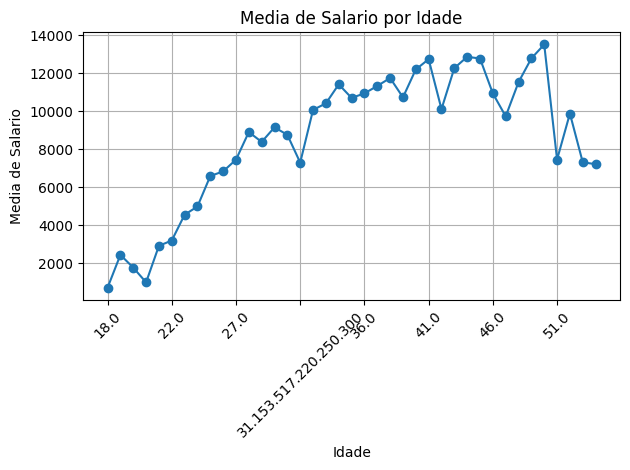

In [ ]:
plt.figure()
plt.plot(salario_por_idade.index, salario_por_idade.values, marker='o', linestyle='-')
plt.title('Media de Salario por Idade')
plt.xlabel('Idade')
plt.ylabel('Media de Salario')
plt.xticks( salario_por_idade.index[::5], rotation= 45)
plt.grid(True)
plt.tight_layout()
plt.show


In [ ]:
import plotly.express as px


In [ ]:
fig = px.line(salario_por_idade.reset_index(), x='IDADE', y='SALARIO', title= 'Media de Salario por Idade', markers=True)
fig.show()

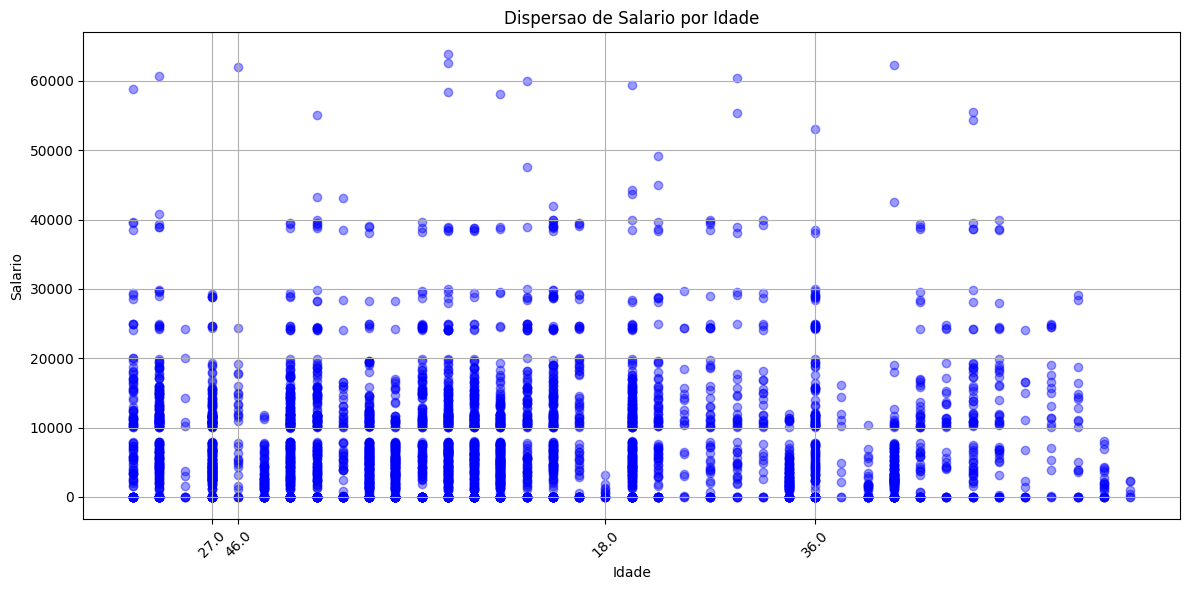

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha=0.4, color='blue')
plt.title('Dispersao de Salario por Idade')
plt.xlabel('Idade')
plt.ylabel('Salario')
#MOSTRAR IDADES 5 EM 5
Idades = sorted(dados['IDADE'].dropna().unique())
plt.xticks(Idades[::10], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()